## Georg Seismic Experiment

Explore seismic signals at Bonn

## Imports

In [14]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
import obspy as obs
import pandas as pd

from obspy.signal import PPSD

from functions.read_sds import __read_sds


## Configurations

In [22]:
config = {}

config['path_to_inv'] = "/home/andbro/kilauea-data/GEORG/stationxml/"

config['path_to_data'] = "/home/andbro/kilauea-data/GEORG/data/"

config['path_to_figs'] = "/home/andbro/kilauea-data/GEORG/figures/"

config['tbeg'] = obs.UTCDateTime("2024-12-16 20:00")
config['tend'] = obs.UTCDateTime("2024-12-17 02:00")


### Seismometer Data

In [23]:
st_seis = __read_sds(config['path_to_data'], "XN.BONN..HH*", config['tbeg'], config['tend'])

inv_seis = obs.read_inventory(config['path_to_inv']+'station_XN_BONN.xml')

print(st_seis)

3 Trace(s) in Stream:
XN.BONN..HHE | 2024-12-16T20:00:00.000000Z - 2024-12-17T02:00:00.000000Z | 200.0 Hz, 4320001 samples
XN.BONN..HHN | 2024-12-16T20:00:00.000000Z - 2024-12-17T02:00:00.000000Z | 200.0 Hz, 4320001 samples
XN.BONN..HHZ | 2024-12-16T20:00:00.000000Z - 2024-12-17T02:00:00.000000Z | 200.0 Hz, 4320001 samples


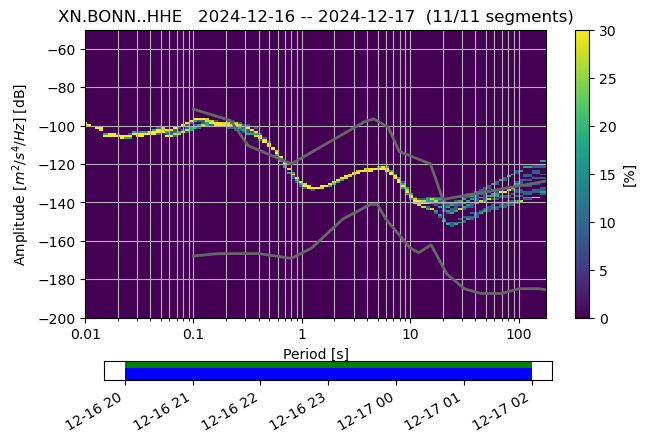

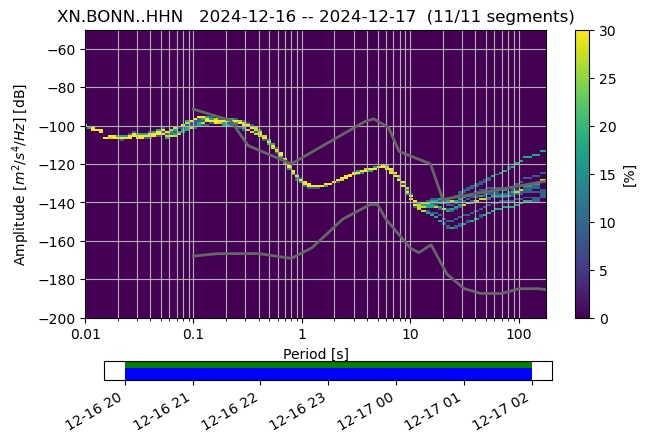

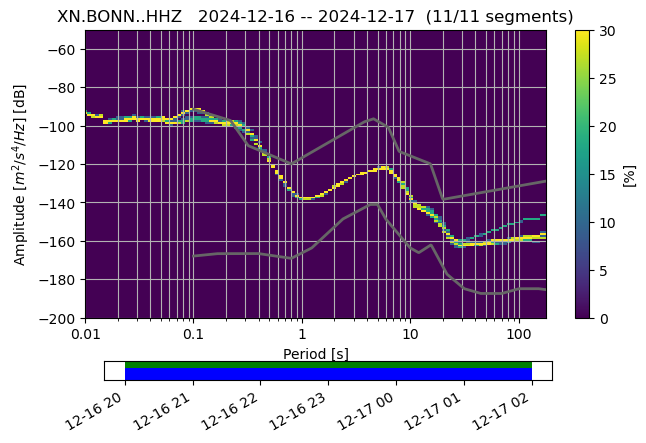

In [24]:
for tr in st_seis:
    ppsd = obs.signal.PPSD(tr.stats, metadata=inv_seis, skip_on_gaps=True)
    ppsd.add(tr)
    ppsd.plot()

### Tiltmeter Data

In [13]:
head = ["time", "north", "east", "X1", "X2", "pressure", "X3", "X4", "X5", "X6"]

tilt = pd.read_csv(config['path_to_data']+"LGMBoxmessung12_16.csv", delimiter=";", names=head)

starttime = obs.UTCDateTime(tilt.time[0])
print(starttime)

mean_dt = tilt.time.diff().mean()
print(mean_dt)

2024-12-16T16:36:15.716615Z
1.0550388852159318


In [14]:
# plt.plot(tilt.time.diff())

In [16]:
tilt

2 Trace(s) in Stream:
LAN... | 2024-12-16T16:36:15.716615Z - 2024-12-17T08:27:11.164489Z | 0.9 Hz, 54080 samples
LAE... | 2024-12-16T16:36:15.716615Z - 2024-12-17T08:27:11.164489Z | 0.9 Hz, 54080 samples

### RaspShake Data

In [30]:
st_rasp = __read_sds(config['path_to_data'], "AM.RACB0.00.EH*", config['tbeg'], config['tend'])

inv_rasp = obs.read_inventory(config['path_to_inv']+"station_AM_RACB0.xml")


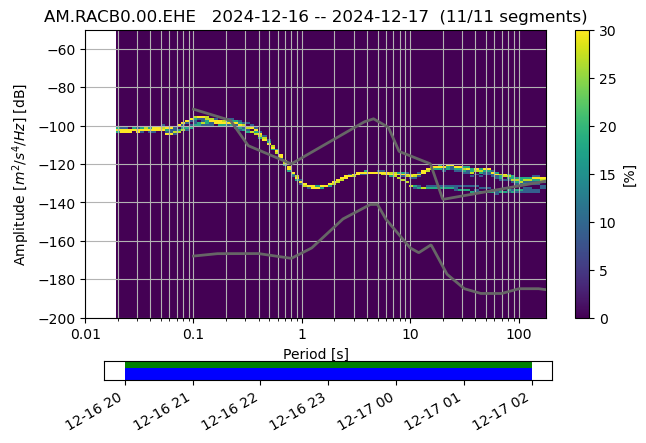

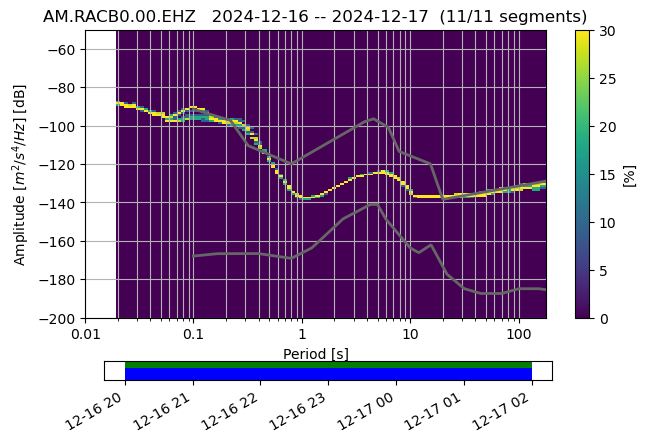

In [31]:
for tr in st_rasp:
    ppsd = obs.signal.PPSD(tr.stats, metadata=inv_rasp)
    ppsd.add(tr)
    ppsd.plot()

In [32]:
st_rasp

2 Trace(s) in Stream:
AM.RACB0.00.EHE | 2024-12-16T19:59:59.997000Z - 2024-12-17T01:59:59.997000Z | 100.0 Hz, 2160001 samples
AM.RACB0.00.EHZ | 2024-12-16T19:59:59.997000Z - 2024-12-17T01:59:59.997000Z | 100.0 Hz, 2160001 samples